# Cross-sectional momentum: an honest monthly backtest

The classic 12-1 momentum factor, end to end on real prices. Signal
computation is a SQL window query, monthly rebalance dates come from
`time_bucket('1mo', ...)`, and the signal table itself is versioned and
snapshotted.

That last part is what most backtest stacks get wrong. Six months from now you
should be able to reproduce *exactly* what this run saw.

The strategy is deliberately vanilla. The h5i-db-native workflow around it is
the point.

In this recipe we:

1. load real daily prices into a versioned table,
2. compute the 12-1 signal on a monthly rebalance grid in one statement,
3. build the portfolio and report an honest, cost-charged P&L,
4. snapshot prices and signals together as the reproducibility layer.

## Terms used here

| term             | meaning |
| ---------------- | --- |
| signal           | a number computed from data that indicates a position to take |
| momentum (12-1)  | buy what has risen over the last twelve months, excluding the most recent one |
| cross-sectional  | ranking assets against each other at one date, not against their own past |
| rebalance        | recomputing target weights and trading to them, on a schedule |
| backtest         | simulating a strategy on historical data |
| basis point (bp) | one hundredth of a percent; trading costs are charged in bp |
| P&L              | profit and loss |
| snapshot         | a named, checksummed pin of table versions, so a rerun reads the same bytes |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa

import h5i_db
from h5i_db import col, count_star, lit, sql_expr, time_bucket, when
import cookbook_utils as cu

db = h5i_db.Database(cu.fresh_db("alpha_momentum"), create=True)

## 1. The data

`cu.fetch_daily` gives real daily bars for 30 large caps, 2018 to 2026, cached
from Yahoo Finance. One row per symbol per session.

| column | type | meaning |
| --- | --- | --- |
| `ts` | `timestamp[us, tz=UTC]` | session date |
| `symbol` | `string` | ticker |
| `open`, `high`, `low`, `close` | `float64` | session prices |
| `adj_close` | `float64` | close adjusted for splits and dividends |
| `volume` | `int64` | shares traded |

In [2]:
daily = cu.fetch_daily(cu.SP500_EXAMPLES, start="2018-01-01", end="2026-07-01")
print(f"{daily.num_rows:,} rows x {daily.num_columns} columns, "
      f"{len(set(daily['symbol'].to_pylist()))} symbols")
daily.to_pandas().head()

64,020 rows x 8 columns, 30 symbols


,ts,symbol,open,high,low,close,adj_close,volume
0,2018-01-02 20:00:00+00:00,AAPL,42.540001,43.075001,42.314999,43.064999,40.267075,102223600
1,2018-01-02 20:00:00+00:00,NVDA,4.894500,4.987500,4.862500,4.983750,4.922529,355616000
2,2018-01-02 20:00:00+00:00,GE,84.251045,86.215950,84.011429,86.168022,80.953125,16185981
3,2018-01-02 20:00:00+00:00,AMZN,58.599998,59.500000,58.525501,59.450500,59.450500,53890000
4,2018-01-02 20:00:00+00:00,IBM,147.705551,148.001907,146.787766,147.466537,102.657249,4395815


We store only what the study needs: `ts`, `symbol` and `adj_close`. The
`sort_key` of `["ts", "symbol"]` makes per-symbol window scans stream in
order.

`append` is strict about that sort key. The input must be ordered by `ts`,
then by `symbol` within each timestamp.

In [3]:
schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("adj_close", pa.float64()),
    ]
)
db.create_table("prices", schema, time_column="ts", sort_key=["ts", "symbol"])

prices = (
    daily.select(["ts", "symbol", "adj_close"])
    .sort_by([("ts", "ascending"), ("symbol", "ascending")])
    .cast(schema)
)
commit = db.append("prices", prices, note="yfinance 30 names 2018-2026")
print(f"version {commit['sequence']}: {commit['rows_total']:,} rows")

version 1: 64,020 rows


## 2. The signal, in one SQL statement

12-1 momentum is the return from 12 months ago to 1 month ago, skipping the
most recent month to avoid short-term reversal. On a trading-day series that
is `lag(px, 21) / lag(px, 252) - 1` per symbol.

The rebalance grid comes from `time_bucket('1mo', ts)`: the last trading day
of each calendar month. Joining the two gives the month-end signal panel, with
no pandas resampling and no calendar edge cases.

In [4]:
def lag_px(n: int):
    """lag(adj_close, n) per symbol - there is no .lag() verb, so sql_expr."""
    return sql_expr(f"lag(adj_close, {n})").over(partition_by="symbol", order_by="ts")


sig = db.table("prices").with_columns(px_1m_ago=lag_px(21), px_12m_ago=lag_px(252))

month_end = (
    db.table("prices")
    .group_by(time_bucket("1mo", col("ts")).alias("month"), "symbol")
    .agg(month_end=col("ts").max())
    .select(col("month_end").alias("ts"), "symbol")
)

panel = (
    sig.join(month_end, on=["ts", "symbol"])
    .select(
        ts=col("ts", relation="l"),
        symbol=col("symbol", relation="l"),
        close=col("adj_close", relation="l"),
        momentum=col("px_1m_ago", relation="l") / col("px_12m_ago", relation="l") - 1,
    )
    .sort(["ts", "symbol"])
    .to_pandas()
)
panel.tail(4)

,ts,symbol,close,momentum
3056,2026-06-30 20:00:00+00:00,UNH,415.630005,0.256115
3057,2026-06-30 20:00:00+00:00,V,343.089996,-0.056430
3058,2026-06-30 20:00:00+00:00,WMT,113.260002,0.199936
3059,2026-06-30 20:00:00+00:00,XOM,136.720001,0.370363


## 3. Portfolio construction and an honest P&L

With only 30 names a "decile" is 3 stocks, so we long the top 10 and short the
bottom 10, equal weight. That is closer to terciles, and less noisy.

The discipline checklist:

- **No lookahead.** The signal observed at month-end *t* earns the return from
  *t* to *t+1*. The last month has no forward return and gets dropped.
- **Costs.** 10 bps of one-way turnover, charged on every weight change,
  including the initial build.
- **Eligibility.** A name needs 252 days of history before it can be ranked,
  and months with fewer than 25 rankable names are skipped.

In [5]:
mom = panel.pivot(index="ts", columns="symbol", values="momentum")
close = panel.pivot(index="ts", columns="symbol", values="close")
fwd_ret = close.pct_change().shift(-1)  # month-end t -> t+1, aligned at t

N_SIDE, COST_BPS = 10, 10
ranks = mom.rank(axis=1)  # NaNs are left unranked
n_valid = mom.notna().sum(axis=1)

weights = pd.DataFrame(0.0, index=mom.index, columns=mom.columns)
weights[ranks.ge(ranks.max(axis=1).to_numpy()[:, None] - N_SIDE + 1)] = 1 / N_SIDE
weights[ranks.le(N_SIDE)] = -1 / N_SIDE
weights.loc[n_valid < 25] = 0.0

turnover = weights.diff().abs().sum(axis=1)
turnover.iloc[0] = weights.iloc[0].abs().sum()

gross = (weights * fwd_ret).sum(axis=1)
net = (gross - COST_BPS / 1e4 * turnover).iloc[:-1]  # drop month with no fwd ret
bench = fwd_ret.mean(axis=1).iloc[:-1]  # equal-weight long-only, no costs


def perf_stats(r: pd.Series, periods: int = 12) -> dict:
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    return {
        "ann_ret": r.mean() * periods,
        "ann_vol": r.std() * np.sqrt(periods),
        "sharpe": r.mean() / r.std() * np.sqrt(periods),
        "max_dd": dd.min(),
    }


stats = pd.DataFrame(
    {"momentum L/S (net)": perf_stats(net), "equal-weight bench": perf_stats(bench)}
).T
print(f"avg monthly one-way turnover: {turnover.mean():.0%}")
stats.round(3)

avg monthly one-way turnover: 70%


,ann_ret,ann_vol,sharpe,max_dd
momentum L/S (net),0.006,0.151,0.042,-0.346
equal-weight bench,0.173,0.155,1.120,-0.179


## 4. Equity curves

The long/short book is roughly market-neutral, so comparing it to a long-only
benchmark is about *shape*, not level. The benchmark rides the 2018 to 2026
bull market while the momentum book mostly treads water.

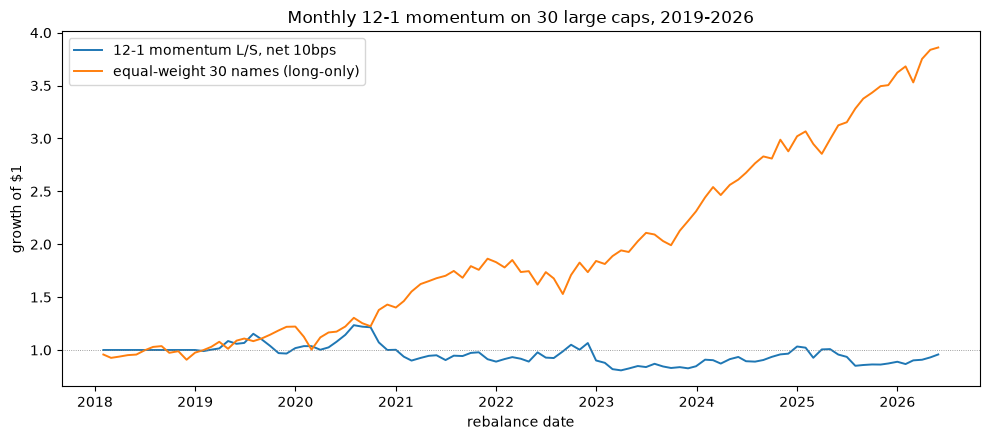

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot((1 + net).cumprod(), label=f"12-1 momentum L/S, net {COST_BPS}bps", lw=1.4)
ax.plot((1 + bench).cumprod(), label="equal-weight 30 names (long-only)", lw=1.4)
ax.axhline(1.0, color="gray", lw=0.6, ls=":")
ax.set_title("Monthly 12-1 momentum on 30 large caps, 2019-2026")
ax.set_xlabel("rebalance date")
ax.set_ylabel("growth of $1")
ax.legend()
fig.tight_layout()

The momentum book lands near a **zero Sharpe** here, and that is not a bug.
Thirty mega caps are a terrible momentum universe, since the premium
historically lives in broader, smaller cross-sections. On top of that, 2020 to
2023 contained brutal momentum crashes.

Resist the urge to tweak lookbacks until the curve looks good. That is how
backtests die. Report it as it is.

## 5. Version the signal: the reproducibility layer

The panel that produced these numbers goes back into h5i-db as a `signals`
table, and a **named snapshot** pins both `prices` and `signals` at this exact
state.

Anyone can later query `h5i('signals', 'mom-run-001')`, or re-read the prices
the run saw, even after both tables have moved on. That is the audit trail a
research platform actually needs.

In [7]:
sig_out = (
    pd.concat(
        [
            mom.stack().rename("momentum"),
            weights.stack().rename("weight"),
        ],
        axis=1,
    )
    .dropna(subset=["momentum"])
    .reset_index()
    .rename(columns={"level_0": "ts", "level_1": "symbol"})
    .sort_values(["ts", "symbol"])
)

sig_schema = pa.schema(
    [
        pa.field("ts", pa.timestamp("us", tz="UTC"), nullable=False),
        pa.field("symbol", pa.string()),
        pa.field("momentum", pa.float64()),
        pa.field("weight", pa.float64()),
    ]
)
db.create_table("signals", sig_schema, time_column="ts", sort_key=["ts", "symbol"])
db.append(
    "signals",
    pa.Table.from_pandas(sig_out, preserve_index=False).cast(sig_schema),
    note="12-1 momentum, top/bottom 10, 10bps",
)
db.snapshot("mom-run-001", tables=["prices", "signals"], note="momentum backtest run 001")

count_if = lambda flag: when(flag).then(lit(1)).otherwise(lit(0)).sum()

(
    db.table("signals", snapshot="mom-run-001")
    .group_by("ts")
    .agg(
        names=count_star(),
        longs=count_if(col("weight") > 0),
        shorts=count_if(col("weight") < 0),
    )
    .sort("ts", descending=True)
    .limit(3)
    .to_pandas()
)

,ts,names,longs,shorts
0,2026-06-30 20:00:00+00:00,30,10,10
1,2026-05-29 20:00:00+00:00,30,10,10
2,2026-04-30 20:00:00+00:00,30,10,10


In [8]:
[
    {k: v[k] for k in ("sequence", "op", "rows", "note") if k in v}
    for v in db.versions("signals")
]

[{'sequence': 0, 'op': 'create', 'rows': 0},
 {'sequence': 1,
  'op': 'append',
  'rows': 2700,
  'note': '12-1 momentum, top/bottom 10, 10bps'}]

## Takeaways

- `lag(...) OVER (PARTITION BY symbol ORDER BY ts)` plus
  `time_bucket('1mo', ts)` turns "compute 12-1 momentum on month-end dates"
  into one SQL statement that streams on sorted storage.
- Backtest hygiene is cheap. Lag the signal one period, charge turnover, drop
  the unknowable last month. Do it every time.
- The result is the honest one: near-zero Sharpe for large-cap momentum, with
  roughly 70% monthly turnover eating 10 bps a side. A universe of 30 mega
  caps is a demo, not an alpha source.
- `db.snapshot("mom-run-001", ...)` pins prices *and* signals in one named,
  queryable state. `h5i('signals', 'mom-run-001')` reproduces this run forever,
  with no CSV archaeology required.

In [9]:
db.close()